## Data Loading

We begin by loading the car insurance dataset, which contains customer demographic and driving-related information. Our goal is to predict whether a customer will file a claim (`CLAIM_FLAG`).

In [ ]:
#Need To Import data 

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

df = pd.read_csv("car_insurance_claim.csv")

df.head()

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,...,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,...,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,...,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,...,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,...,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban


## Data Understanding

The dataset contains 10,302 observations and 27 features, including demographic, financial, and driving-related variables.

Key observations:
- Some variables such as INCOME and HOME_VAL are stored as strings instead of numeric values.
- Several columns contain missing values (e.g., YOJ, INCOME, OCCUPATION).
- The target variable is `CLAIM_FLAG`, which is binary (0 = no claim, 1 = claim).

In [43]:
#Need to find out what the others columns are and what they mean.
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   BIRTH       10302 non-null  str    
 3   AGE         10295 non-null  float64
 4   HOMEKIDS    10302 non-null  int64  
 5   YOJ         9754 non-null   float64
 6   INCOME      9732 non-null   str    
 7   PARENT1     10302 non-null  str    
 8   HOME_VAL    9727 non-null   str    
 9   MSTATUS     10302 non-null  str    
 10  GENDER      10302 non-null  str    
 11  EDUCATION   10302 non-null  str    
 12  OCCUPATION  9637 non-null   str    
 13  TRAVTIME    10302 non-null  int64  
 14  CAR_USE     10302 non-null  str    
 15  BLUEBOOK    10302 non-null  str    
 16  TIF         10302 non-null  int64  
 17  CAR_TYPE    10302 non-null  str    
 18  RED_CAR     10302 non-null  str    
 19  OLDCLAIM    10302 non-null  str    


,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,TRAVTIME,TIF,CLM_FREQ,MVR_PTS,CAR_AGE,CLAIM_FLAG
count,1.030200e+04,10302.000000,10295.000000,10302.000000,9754.000000,10302.000000,10302.000000,10302.000000,10302.000000,9663.000000,10302.000000
mean,4.956631e+08,0.169288,44.837397,0.720443,10.474062,33.416424,5.329159,0.800718,1.710153,8.298148,0.266550
std,2.864675e+08,0.506512,8.606445,1.116323,4.108943,15.869687,4.110795,1.154079,2.159015,5.714450,0.442177
min,6.317500e+04,0.000000,16.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,-3.000000,0.000000
25%,2.442869e+08,0.000000,39.000000,0.000000,9.000000,22.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,4.970043e+08,0.000000,45.000000,0.000000,11.000000,33.000000,4.000000,0.000000,1.000000,8.000000,0.000000
75%,7.394551e+08,0.000000,51.000000,1.000000,13.000000,44.000000,7.000000,2.000000,3.000000,12.000000,1.000000
max,9.999264e+08,4.000000,81.000000,5.000000,23.000000,142.000000,25.000000,5.000000,13.000000,28.000000,1.000000


## Missing Values

Several columns contain missing values, including:
- YOJ (Years on Job)
- INCOME
- OCCUPATION
- CAR_AGE

These missing values must be handled before modeling.

In [44]:
#Checking for null values
df.isnull().sum()

ID              0
KIDSDRIV        0
BIRTH           0
AGE             7
HOMEKIDS        0
YOJ           548
INCOME        570
PARENT1         0
HOME_VAL      575
MSTATUS         0
GENDER          0
EDUCATION       0
OCCUPATION    665
TRAVTIME        0
CAR_USE         0
BLUEBOOK        0
TIF             0
CAR_TYPE        0
RED_CAR         0
OLDCLAIM        0
CLM_FREQ        0
REVOKED         0
MVR_PTS         0
CLM_AMT         0
CAR_AGE       639
CLAIM_FLAG      0
URBANICITY      0
dtype: int64

## Duplicate Records

We identified and removed duplicate records to ensure data quality. Only 1 duplicate was found and removed.

In [45]:
#Checking for duplicates
df.duplicated().sum()

1

In [46]:
#viewing the duplicates
df[df.duplicated(keep=False)]

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
6036,279799481,0,21FEB60,39.0,0,14.0,"$93,077",No,"$244,764",Yes,...,Minivan,yes,$0,0,No,0,$0,1.0,0,z_Highly Rural/ Rural
9801,279799481,0,21FEB60,39.0,0,14.0,"$93,077",No,"$244,764",Yes,...,Minivan,yes,$0,0,No,0,$0,1.0,0,z_Highly Rural/ Rural


In [47]:
#Remove duplicates 
df = df.drop_duplicates()

In [48]:
df = df.reset_index(drop=True)
df.duplicated().sum()

0

## CLEANING DATA 

In [49]:
#CLEANING THE DATA,

#CLEANING INCOME
df["INCOME"] = df["INCOME"].replace('[\$,]', '', regex=True).astype(float)
#CLEANING OLDCLAIM
df["OLDCLAIM"] = df["OLDCLAIM"].replace('[\$,]', '', regex=True).astype(float)

In [50]:
#MISSING VALUES IN AGE, INCOME AND CAR_AGE
df["AGE"] = df["AGE"].fillna(df["AGE"].median())

df["CAR_AGE"] = df["CAR_AGE"].fillna(df["CAR_AGE"].median())

df["INCOME"] = df["INCOME"].fillna(df["INCOME"].median())
#Making sure there are no more null values in the columns
df[["AGE", "CAR_AGE", "INCOME"]].isnull().sum()

AGE        0
CAR_AGE    0
INCOME     0
dtype: int64

For this analysis, only variables relevant to predicting insurance claims were selected. Missing values were handled for the features included in the modeling dataset, specifically age and vehicle age, using median imputation.

## Target Variable Analysis

The target variable `CLAIM_FLAG` is imbalanced:
- ~73% of customers did not file a claim
- ~27% filed a claim

This imbalance is important because accuracy alone will not be a reliable evaluation metric. Instead, metrics such as recall, precision, and F1-score will be used.

In [51]:
df["CLAIM_FLAG"].value_counts(normalize=True)

CLAIM_FLAG
0    0.733424
1    0.266576
Name: proportion, dtype: float64

<Axes: xlabel='CLAIM_FLAG', ylabel='count'>

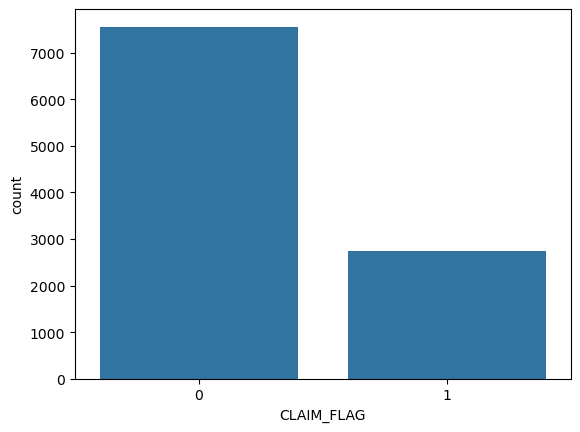

In [52]:
import seaborn as sns
sns.countplot(x="CLAIM_FLAG", data=df)

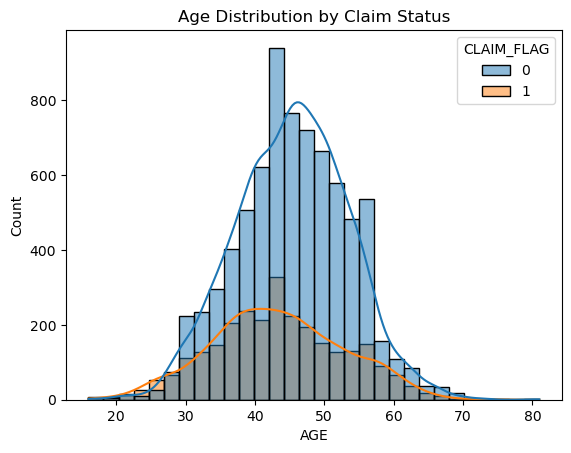

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="AGE", hue="CLAIM_FLAG", bins=30, kde=True)
plt.title("Age Distribution by Claim Status")
plt.show()

Age alone may not be a strong predictor but could contribute when combined with other variables.

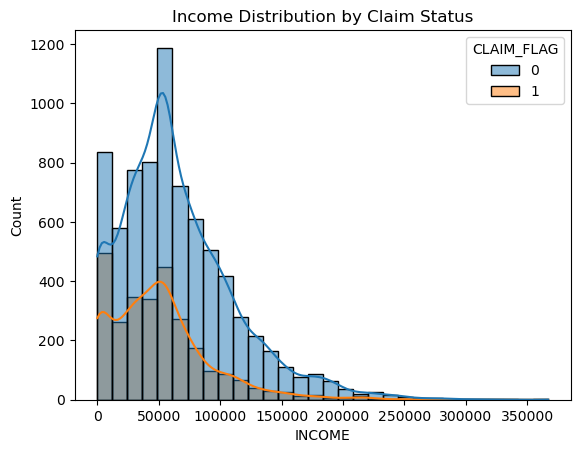

In [105]:
sns.histplot(data=df, x="INCOME", hue="CLAIM_FLAG", bins=30, kde=True)
plt.title("Income Distribution by Claim Status")
plt.show()

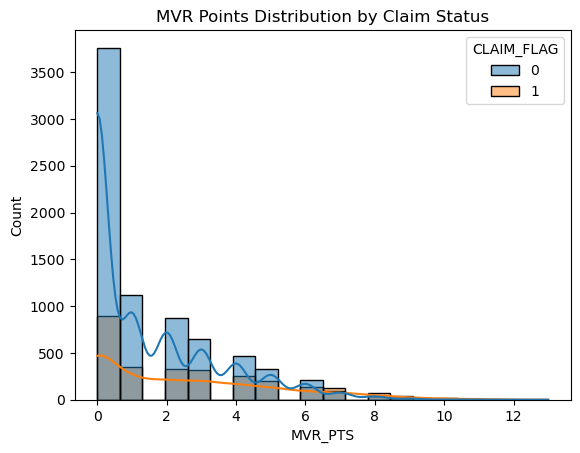

In [106]:
sns.histplot(data=df, x="MVR_PTS", hue="CLAIM_FLAG", bins=20, kde=True)
plt.title("MVR Points Distribution by Claim Status")
plt.show()

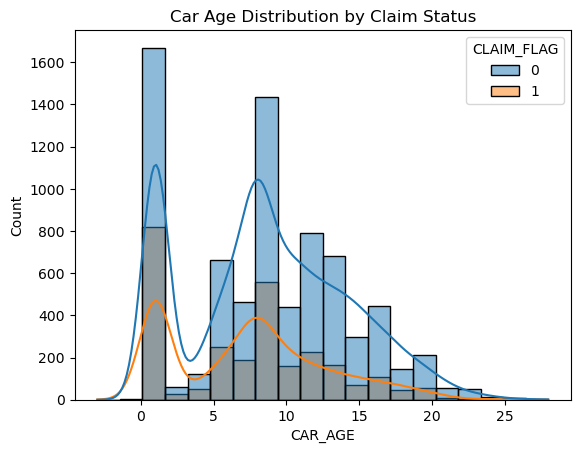

In [107]:
sns.histplot(data=df, x="CAR_AGE", hue="CLAIM_FLAG", bins=20, kde=True)
plt.title("Car Age Distribution by Claim Status")
plt.show()

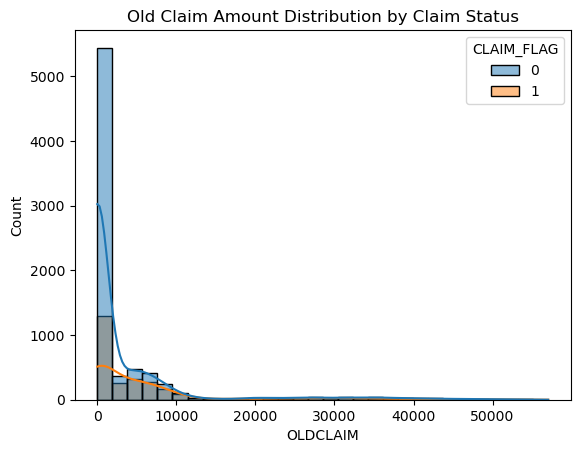

In [108]:
sns.histplot(data=df, x="OLDCLAIM", hue="CLAIM_FLAG", bins=30, kde=True)
plt.title("Old Claim Amount Distribution by Claim Status")
plt.show()

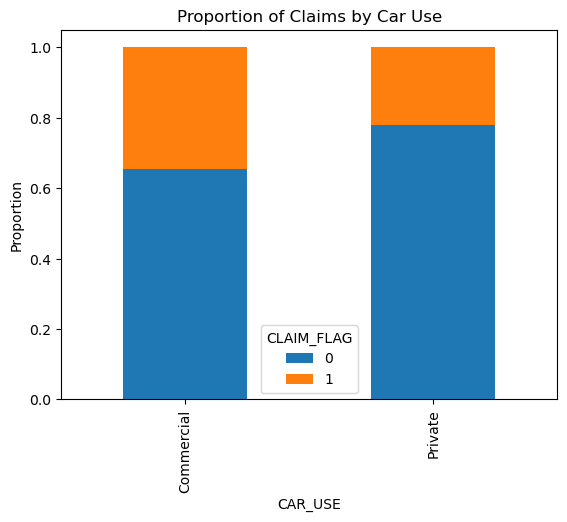

In [109]:
pd.crosstab(df["CAR_USE"], df["CLAIM_FLAG"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proportion of Claims by Car Use")
plt.ylabel("Proportion")
plt.show()

Commercial vehicle use appears to have a higher proportion of claims compared to private use, suggesting that driving purpose influences risk.

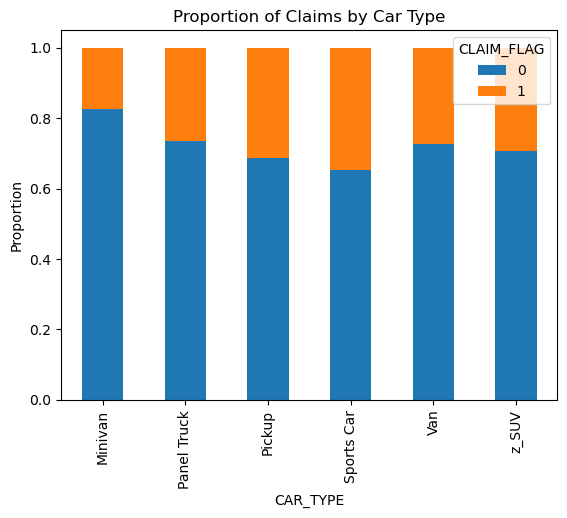

In [110]:
pd.crosstab(df["CAR_TYPE"], df["CLAIM_FLAG"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proportion of Claims by Car Type")
plt.ylabel("Proportion")
plt.show()

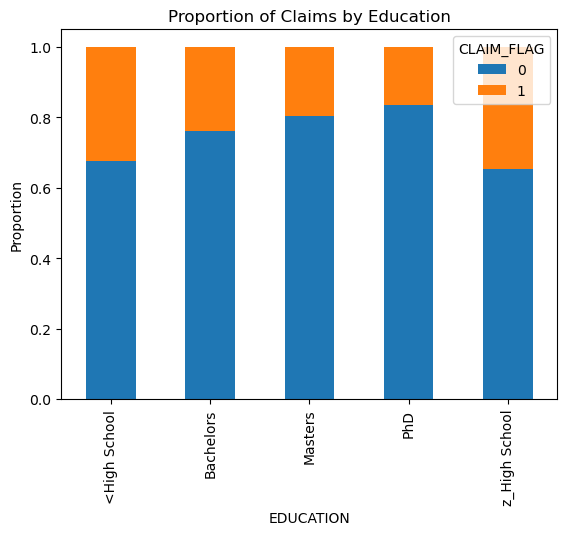

In [111]:
pd.crosstab(df["EDUCATION"], df["CLAIM_FLAG"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proportion of Claims by Education")
plt.ylabel("Proportion")
plt.show()

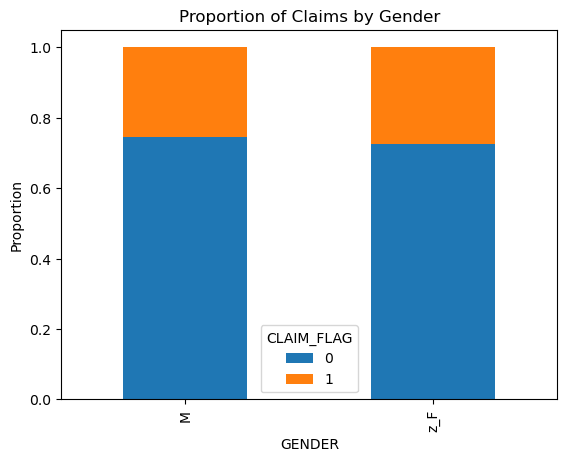

In [112]:
pd.crosstab(df["GENDER"], df["CLAIM_FLAG"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proportion of Claims by Gender")
plt.ylabel("Proportion")
plt.show()

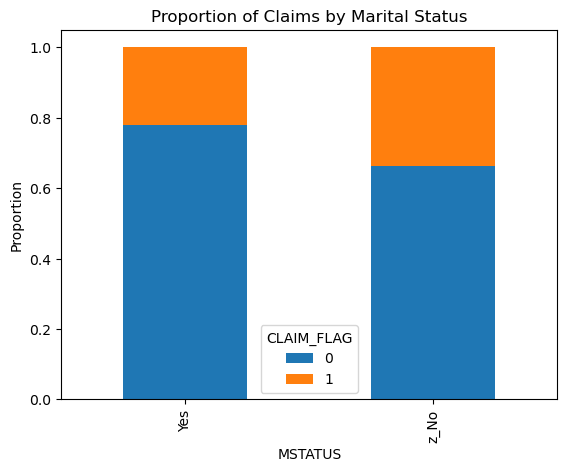

In [113]:
pd.crosstab(df["MSTATUS"], df["CLAIM_FLAG"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proportion of Claims by Marital Status")
plt.ylabel("Proportion")
plt.show()

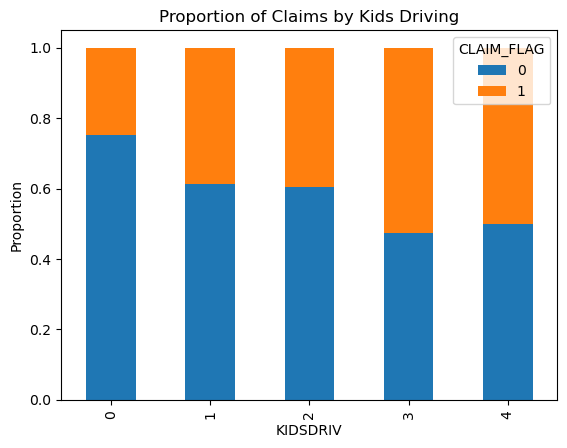

In [114]:
pd.crosstab(df["KIDSDRIV"], df["CLAIM_FLAG"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Proportion of Claims by Kids Driving")
plt.ylabel("Proportion")
plt.show()

## Feature Selection

The following features were selected based on their relevance to predicting insurance claims:

- Demographics: AGE, GENDER, EDUCATION, MSTATUS
- Financial: INCOME
- Vehicle-related: CAR_TYPE, CAR_AGE, CAR_USE
- Driving history: MVR_PTS, OLDCLAIM, CLM_FREQ, REVOKED
- Location: URBANICITY
- Household: KIDSDRIV

These variables are expected to influence claim likelihood based on risk behavior and customer profile.

In [115]:
money_cols = ["INCOME", "OLDCLAIM"]

for col in money_cols:
    df[col] = df[col].replace(r"[\$,]", "", regex=True).astype(float)

In [116]:
#Selecting the features and target variable for modeling
features = [
    "AGE",
    "GENDER",
    "EDUCATION",
    "INCOME",
    "CAR_TYPE",
    "CAR_AGE",
    "MSTATUS",
    "CAR_USE",
    "MVR_PTS",
    "OLDCLAIM",
    "CLM_FREQ",
    "REVOKED",
    "URBANICITY",
    "KIDSDRIV"
]

X = df[features]
y = df["CLAIM_FLAG"]



In [117]:
print(X.head())
print(y.head())

    AGE GENDER      EDUCATION   INCOME CAR_TYPE  CAR_AGE MSTATUS     CAR_USE  \
0  60.0      M            PhD  67349.0  Minivan     18.0    z_No     Private   
1  43.0      M  z_High School  91449.0  Minivan      1.0    z_No  Commercial   
2  48.0      M      Bachelors  52881.0      Van     10.0    z_No     Private   
3  35.0    z_F  z_High School  16039.0    z_SUV     10.0     Yes     Private   
4  51.0      M   <High School  53526.0  Minivan      6.0     Yes     Private   

   MVR_PTS  OLDCLAIM  CLM_FREQ REVOKED           URBANICITY  KIDSDRIV  
0        3    4461.0         2      No  Highly Urban/ Urban         0  
1        0       0.0         0      No  Highly Urban/ Urban         0  
2        2       0.0         0      No  Highly Urban/ Urban         0  
3        3   38690.0         2      No  Highly Urban/ Urban         0  
4        0       0.0         0      No  Highly Urban/ Urban         0  
0    0
1    0
2    0
3    0
4    0
Name: CLAIM_FLAG, dtype: int64


## TRAIN DATA 

In [ ]:

#TRAIN THE DATA
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [121]:
#CLASSIFYING THE DATA
numeric_features = [
    "AGE",
    "INCOME",
    "CAR_AGE",
    "MVR_PTS",
    "OLDCLAIM",
    "CLM_FREQ",
    "KIDSDRIV"
]

categorical_features = [
    "GENDER",
    "EDUCATION",
    "CAR_TYPE",
    "MSTATUS",
    "CAR_USE",
    "REVOKED",
    "URBANICITY"
]

## BUILDING PREPROCESSING PIPELINES

In [122]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Model Evaluation - Logistic Regression

To evaluate model performance, we use:
- Classification Report (precision, recall, F1-score)
- Confusion Matrix
- ROC Curve and AUC Score

Due to class imbalance, recall is a key metric, as it measures the model’s ability to correctly identify claim cases.

In [124]:
#LOGICSTIC REGRESSION
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Handling Class Imbalance

The target variable `CLAIM_FLAG` is imbalanced, with significantly more non-claim cases than claim cases.

To address this, we used `class_weight='balanced'` in Logistic Regression. This adjusts the importance of each class during training, ensuring that the model pays more attention to the minority class (claims).

This is important from a business perspective, as failing to identify high-risk customers can lead to financial losses.

In [125]:
#PREDICTIONS
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = logreg_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.71      0.78      1512
           1       0.48      0.73      0.58       549

    accuracy                           0.71      2061
   macro avg       0.68      0.72      0.68      2061
weighted avg       0.77      0.71      0.73      2061



The model shows improved performance in identifying claim cases, with recall for class 1 increasing to approximately 0.73.

This indicates that the model is now correctly identifying a much larger proportion of high-risk customers compared to earlier results.

While precision for class 1 is lower, this trade-off is acceptable from a business perspective, as identifying more potential claims is more valuable than missing them.

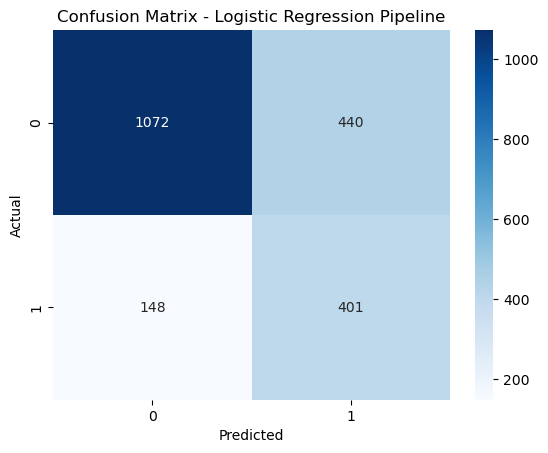

In [140]:
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows a significant improvement in detecting claim cases.

- True Positives: 401 (correctly identified claims)
- False Negatives: 148 (missed claims)

Compared to earlier results, the model now captures a much larger portion of actual claims, reducing the risk of overlooking high-risk customers.

This improvement is especially important for insurance decision-making, where missing risky clients can lead to financial losses.

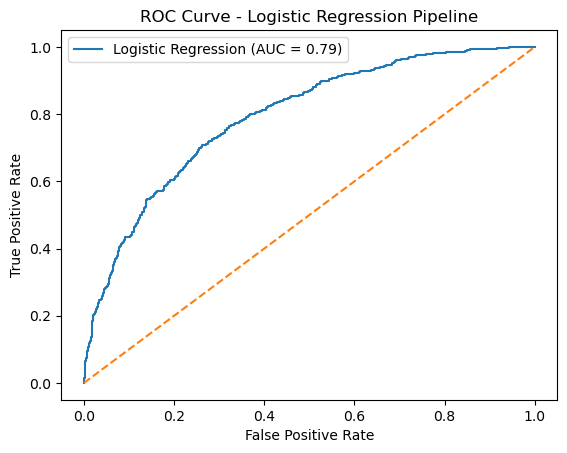

In [129]:
from sklearn.metrics import roc_curve, auc

y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Pipeline")
plt.legend()
plt.show()

## Feature Importance - Logistic Regression

To better understand the model, we analyze feature importance using the coefficients from Logistic Regression.

Positive coefficients increase the likelihood of a claim, while negative coefficients decrease it.

In [132]:
model = logreg_pipeline.named_steps["classifier"]
feature_names = logreg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient")

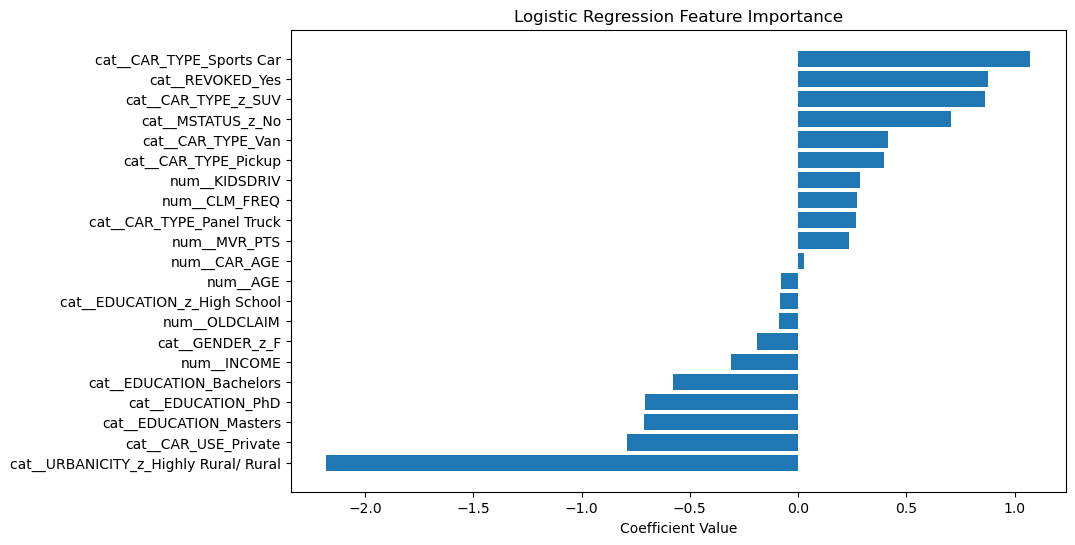

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()

In [134]:
coefficients.head(10)   # Top NEGATIVE drivers

,Feature,Coefficient
20,cat__URBANICITY_z_Highly Rural/ Rural,-2.180358
18,cat__CAR_USE_Private,-0.791811
9,cat__EDUCATION_Masters,-0.712448
10,cat__EDUCATION_PhD,-0.706972
8,cat__EDUCATION_Bachelors,-0.576827
1,num__INCOME,-0.308556
7,cat__GENDER_z_F,-0.190353
4,num__OLDCLAIM,-0.089924
11,cat__EDUCATION_z_High School,-0.082436
0,num__AGE,-0.080398


In [135]:
coefficients.tail(10)   # Top POSITIVE drivers

,Feature,Coefficient
3,num__MVR_PTS,0.233847
12,cat__CAR_TYPE_Panel Truck,0.269100
5,num__CLM_FREQ,0.271471
6,num__KIDSDRIV,0.283772
13,cat__CAR_TYPE_Pickup,0.398135
15,cat__CAR_TYPE_Van,0.417108
17,cat__MSTATUS_z_No,0.706427
16,cat__CAR_TYPE_z_SUV,0.863095
19,cat__REVOKED_Yes,0.878214
14,cat__CAR_TYPE_Sports Car,1.073192


## Key Insights from Feature Importance

The model highlights several important drivers of insurance claims:

- **Driving behavior variables** such as MVR_PTS and CLM_FREQ have strong positive coefficients, indicating that riskier driving history significantly increases claim likelihood.
- **License status (REVOKED)** is also a strong predictor, suggesting that drivers with revoked licenses are higher risk.
- Certain **vehicle types (e.g., SUVs, sports cars)** are associated with higher claim probability.
- **Urbanicity** shows a strong negative relationship for rural areas, suggesting that drivers in less populated areas may have lower claim risk.
- **Private car use** is associated with lower claim likelihood compared to commercial use.

These insights provide valuable guidance for underwriting and pricing strategies in insurance.

## RANDOM FOREST MODEL

## Handling Class Imbalance - Random Forest

To address class imbalance, we applied `class_weight='balanced'` in the Random Forest model. This ensures that the model gives more importance to the minority class (claims), improving its ability to detect high-risk customers.

In [136]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1512
           1       0.64      0.34      0.44       549

    accuracy                           0.77      2061
   macro avg       0.72      0.64      0.65      2061
weighted avg       0.75      0.77      0.75      2061



The Random Forest model shows lower recall for claim cases compared to Logistic Regression, indicating that it struggles to identify high-risk customers.

Even though Random Forest captures complex relationships, it may not perform as well in this case due to class imbalance and the nature of the dataset.

Therefore, Logistic Regression currently provides better performance for identifying claim cases.

In [137]:
import pandas as pd

rf_model = rf_pipeline.named_steps["classifier"]
feature_names_rf = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

plt.show()

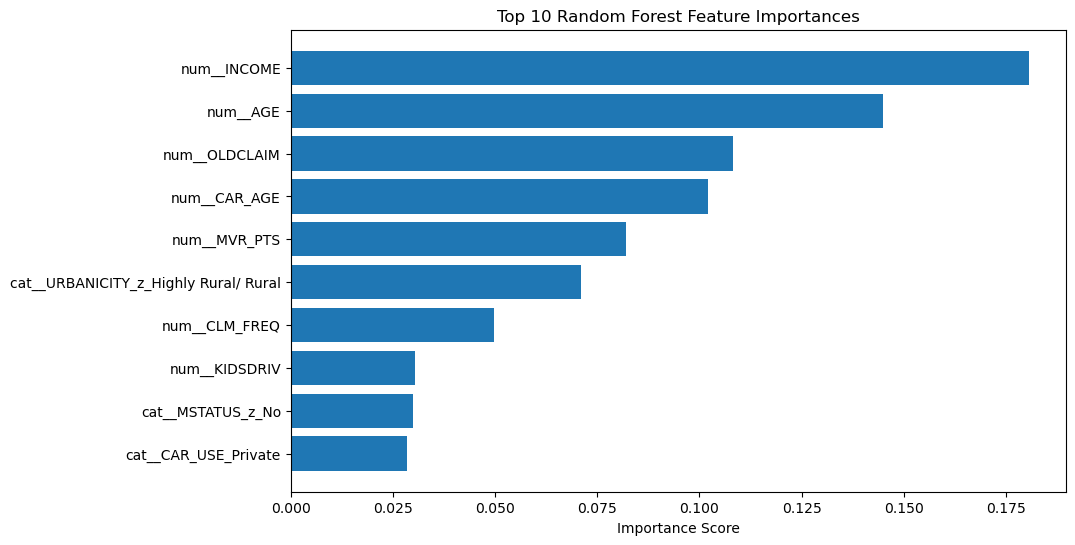

In [138]:
plt.figure(figsize=(10,6))
plt.barh(rf_importance["Feature"][:10][::-1], rf_importance["Importance"][:10][::-1])
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.show()

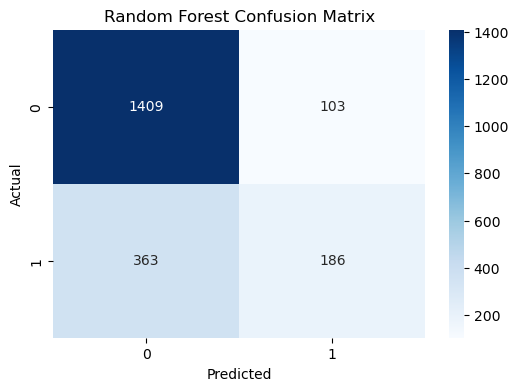

In [139]:
#CONFUSION MATRIX FOR RANDOM FOREST
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The number of False Negative went down in this model to 363 but so did the True Positive compared to the prior model

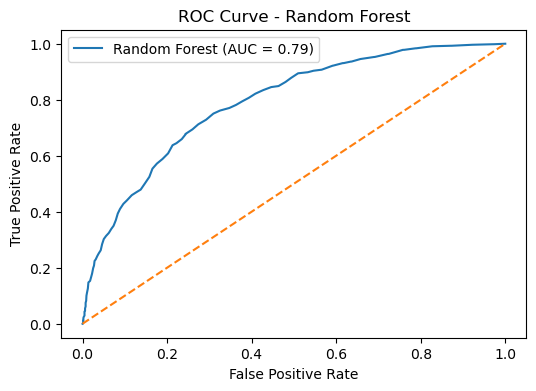

Random Forest AUC Score: 0.7897000077100259


In [141]:
#ROC CURVE FOR RANDOM FOREST
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("Random Forest AUC Score:", roc_auc_rf)

The Random Forest model captures non-linear relationships in the data, but its performance should be compared against Logistic Regression based on recall for claim cases.

Feature importance shows which variables contribute most strongly to classification decisions, helping identify the main drivers of insurance risk.

## GRADIENT BOOSTING

Gradient Boosting does not directly support `class_weight`, so class imbalance was addressed using sample weights during training.

This approach gives more importance to the minority class (claim cases), helping the model better identify high-risk customers.

In [142]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [144]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])
gb_pipeline.fit(
    X_train,
    y_train,
    classifier__sample_weight=sample_weights
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [145]:
from sklearn.metrics import classification_report

y_pred_gb = gb_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1512
           1       0.50      0.76      0.60       549

    accuracy                           0.73      2061
   macro avg       0.69      0.74      0.70      2061
weighted avg       0.79      0.73      0.74      2061



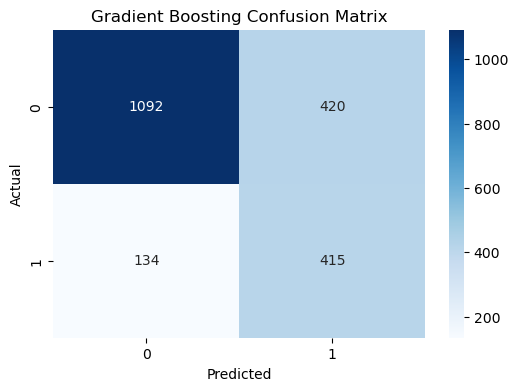

In [146]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

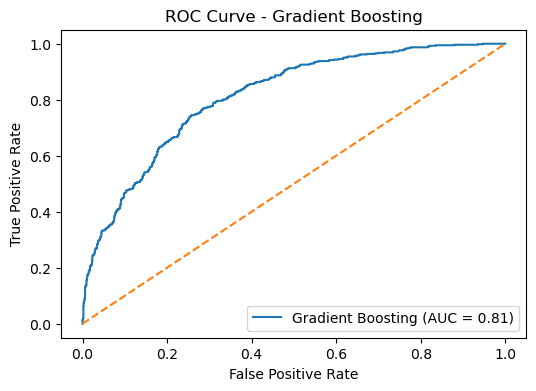

Gradient Boosting AUC Score: 0.8127276867030966


In [147]:
from sklearn.metrics import roc_curve, auc

y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(6,4))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_gb:.2f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

print("Gradient Boosting AUC Score:", roc_auc_gb)

In [148]:
import pandas as pd

gb_model = gb_pipeline.named_steps["classifier"]
feature_names_gb = gb_pipeline.named_steps["preprocessor"].get_feature_names_out()

gb_importance = pd.DataFrame({
    "Feature": feature_names_gb,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

gb_importance.head(10)

,Feature,Importance
4,num__OLDCLAIM,0.235306
20,cat__URBANICITY_z_Highly Rural/ Rural,0.207076
1,num__INCOME,0.136902
0,num__AGE,0.073694
18,cat__CAR_USE_Private,0.069489
6,num__KIDSDRIV,0.063032
17,cat__MSTATUS_z_No,0.053914
3,num__MVR_PTS,0.040188
19,cat__REVOKED_Yes,0.039433
2,num__CAR_AGE,0.025475


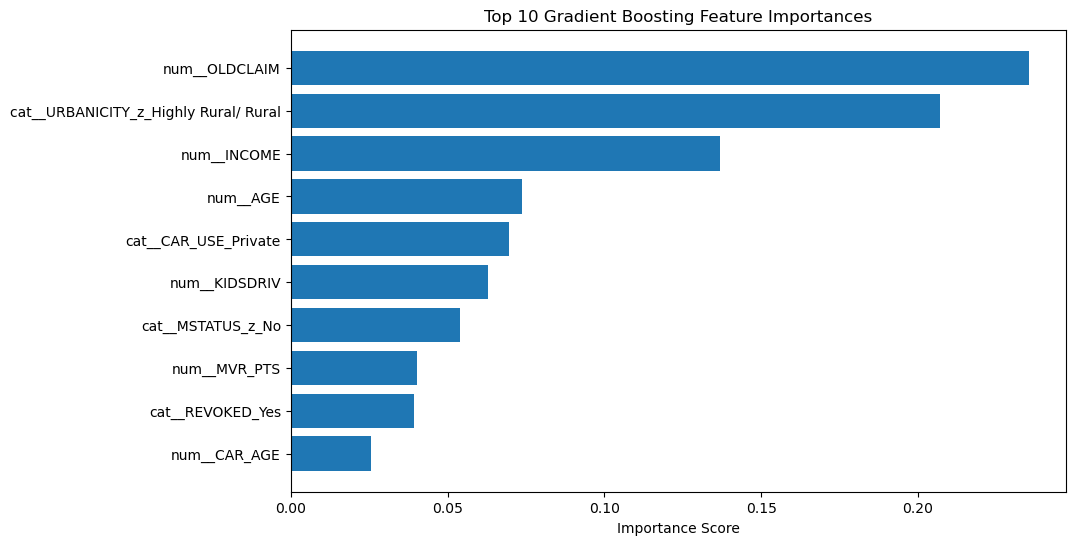

In [149]:
plt.figure(figsize=(10,6))
plt.barh(gb_importance["Feature"][:10][::-1], gb_importance["Importance"][:10][::-1])
plt.title("Top 10 Gradient Boosting Feature Importances")
plt.xlabel("Importance Score")
plt.show()

The Gradient Boosting model was trained using sample weights to address class imbalance. This allows the model to pay greater attention to claim cases during training.

Its performance should be compared with Logistic Regression and Random Forest, with particular emphasis on recall for class 1, since identifying claim cases is the primary business objective.

## Model Comparison

Three models were evaluated:

- Logistic Regression (with class balancing)
- Random Forest
- Gradient Boosting

